# 07 — Do Neighbouring Links Actually Help? (Testing the Premise)

Notebook 06 ended by naming the most promising next step: give the model
**cross-link features**, so it can see what neighbouring links are doing rather
than only a single link's own past. The reasoning was that notebook 03 found
adjacent corridor links correlated at **0.997**, and that 14% of timesteps have
five or more links Critical at once — signal that persistence structurally cannot
use.

Building those features and retraining is roughly half an hour of compute. Before
spending it, this notebook checks whether the premise survives contact with the
data.

**It does not**, and the reason is worth understanding — it says something real
about what this dataset can and cannot support.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT = Path.cwd().parent
PROCESSED = PROJECT / "data" / "processed"
RAW = PROJECT / "data" / "raw" / "abilene"

utilisation = pd.read_parquet(PROCESSED / "abilene_link_utilization_wide.parquet")
utilisation.index = pd.DatetimeIndex(utilisation.index)
grid = utilisation.asfreq("5min")     # regular spacing, so shifts mean real time

pd.set_option("display.width", 200)
print(f"{utilisation.shape[0]:,} timesteps x {utilisation.shape[1]} links")

48,096 timesteps x 30 links


In [2]:
BLUE, ORANGE, GREY = "#2a78d6", "#eb6834", "#c3c2b7"
INK, MUTED = "#0b0b0b", "#898781"

plt.rcParams.update({
    "figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False,
    "axes.edgecolor": GREY, "axes.labelcolor": MUTED, "axes.titlecolor": INK,
    "axes.titlesize": 11, "axes.titleweight": "bold", "axes.axisbelow": True,
    "xtick.color": MUTED, "ytick.color": MUTED,
    "grid.color": "#e1e0d9", "grid.linewidth": 0.6,
    "font.size": 9, "legend.frameon": False,
})
print("style set")

style set


## The test

Correlation on its own does not make a feature useful. If two links move in
perfect lockstep **at the same instant**, the neighbour tells you nothing you did
not already know from the link itself — it is redundant, not predictive.

What would make a cross-link feature earn its place is if some neighbour's value
*k* steps ago predicts this link's value now **better than the link's own value
*k* steps ago does**. So for every link L and every lag k:

- `self` = corr( L(t), L(t−k) ) — what the lag features and persistence already use
- `best` = the highest corr( L(t), N(t−k) ) over all other links N

A neighbour only adds something when `best > self`.

In [3]:
LAGS = {3: "15 min", 6: "30 min"}
links = list(grid.columns)
summaries = {}

for k, label in LAGS.items():
    shifted = grid.shift(k)
    rows = []
    for target_link in links:
        target = grid[target_link]
        self_corr = target.corr(shifted[target_link])
        neighbours = {n: target.corr(shifted[n]) for n in links if n != target_link}
        best = max(neighbours, key=neighbours.get)
        rows.append({
            "link": target_link,
            "self": self_corr,
            "best_neighbour": best,
            "neighbour_corr": neighbours[best],
            "advantage": neighbours[best] - self_corr,
        })
    summaries[k] = pd.DataFrame(rows).sort_values("advantage", ascending=False)

    print("=" * 92)
    print(f"LAG {k} steps ({label})")
    print("=" * 92)
    print(summaries[k].head(6).round(4).to_string(index=False))
    better = (summaries[k].advantage > 0).sum()
    print(f"\nlinks where SOME neighbour beats the link's own history: "
          f"{better} / {len(links)}")
    print(f"median advantage {summaries[k].advantage.median():+.4f}   "
          f"best advantage {summaries[k].advantage.max():+.4f}\n")

LAG 3 steps (15 min)
         link   self best_neighbour  neighbour_corr  advantage
IPLSng,KSCYng 0.7542  CHINng,IPLSng          0.7548     0.0006
DNVRng,KSCYng 0.8553  KSCYng,IPLSng          0.8551    -0.0002
SNVAng,DNVRng 0.8465  LOSAng,SNVAng          0.8454    -0.0011
KSCYng,IPLSng 0.8569  DNVRng,KSCYng          0.8553    -0.0016
DNVRng,SNVAng 0.6900  KSCYng,DNVRng          0.6882    -0.0018
LOSAng,SNVAng 0.8478  SNVAng,DNVRng          0.8455    -0.0023

links where SOME neighbour beats the link's own history: 1 / 30
median advantage -0.1688   best advantage +0.0006



LAG 6 steps (30 min)
         link   self best_neighbour  neighbour_corr  advantage
IPLSng,KSCYng 0.6743  CHINng,IPLSng          0.6759     0.0016
DNVRng,KSCYng 0.8039  KSCYng,IPLSng          0.8040     0.0001
DNVRng,SNVAng 0.5895  KSCYng,DNVRng          0.5889    -0.0006
SNVAng,DNVRng 0.7922  LOSAng,SNVAng          0.7915    -0.0007
KSCYng,IPLSng 0.8060  DNVRng,KSCYng          0.8043    -0.0017
LOSAng,SNVAng 0.7940  SNVAng,DNVRng          0.7915    -0.0025

links where SOME neighbour beats the link's own history: 2 / 30
median advantage -0.1412   best advantage +0.0016



The answer is unambiguous.

At 15 minutes, exactly **1 link out of 30** has any neighbour that beats its own
history, and the margin is **+0.0006** — noise. At 30 minutes it is 2 out of 30,
best margin **+0.0016**.

The median link is **0.14–0.17 correlation worse** off using its best neighbour
than using itself. Neighbours are not a slightly-worse substitute for a link's own
history; they are substantially worse, and never meaningfully better.

## Why: there is no lead, only simultaneity

The 0.997 correlation from notebook 03 is real. The question is *when* it peaks.
If congestion propagated along a path — upstream link congests, then downstream a
few minutes later — the correlation would peak at a positive lag and there would
be something to predict from.

In [4]:
corridor = ["CHINng,IPLSng", "IPLSng,KSCYng", "KSCYng,DNVRng",
            "DNVRng,SNVAng", "SNVAng,LOSAng"]

print("peak correlation between consecutive corridor hops, and at what lag:\n")
peaks = []
for upstream, downstream in zip(corridor, corridor[1:]):
    values = {k: grid[downstream].corr(grid[upstream].shift(k))
              for k in range(-12, 13)}
    best_lag = max(values, key=values.get)
    peaks.append({"upstream": upstream, "downstream": downstream,
                  "peak_corr": values[best_lag],
                  "at_lag_steps": best_lag,
                  "at_lag_min": best_lag * 5})
    print(f"  {upstream:<16} -> {downstream:<16} "
          f"peak {values[best_lag]:.4f} at {best_lag:+d} steps "
          f"({best_lag * 5:+d} min)")

print("\nlag 0 means they move together - the upstream link does not lead.")

peak correlation between consecutive corridor hops, and at what lag:

  CHINng,IPLSng    -> IPLSng,KSCYng    peak 0.9973 at +0 steps (+0 min)
  IPLSng,KSCYng    -> KSCYng,DNVRng    peak 0.8508 at +0 steps (+0 min)
  KSCYng,DNVRng    -> DNVRng,SNVAng    peak 0.9945 at +0 steps (+0 min)


  DNVRng,SNVAng    -> SNVAng,LOSAng    peak 0.9944 at +0 steps (+0 min)

lag 0 means they move together - the upstream link does not lead.


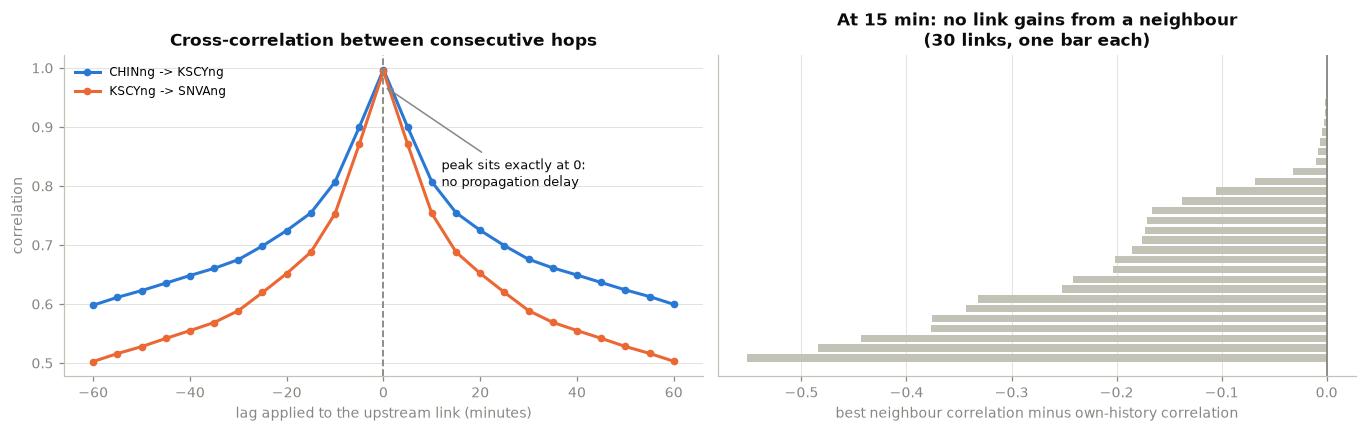

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4))

# Left: the cross-correlation function for two corridor pairs.
lags = range(-12, 13)
for (a, b), colour in zip([("CHINng,IPLSng", "IPLSng,KSCYng"),
                           ("KSCYng,DNVRng", "DNVRng,SNVAng")], [BLUE, ORANGE]):
    values = [grid[b].corr(grid[a].shift(k)) for k in lags]
    axes[0].plot([k * 5 for k in lags], values, marker="o", markersize=4,
                 linewidth=2, color=colour, label=f"{a.split(',')[0]} -> {b.split(',')[1]}")
axes[0].axvline(0, color=MUTED, linestyle="--", linewidth=1.2)
axes[0].annotate("peak sits exactly at 0:\nno propagation delay",
                 xy=(0, 0.97), xytext=(12, 0.80), color=INK, fontsize=8.5,
                 arrowprops=dict(arrowstyle="->", color=MUTED, linewidth=1))
axes[0].set_xlabel("lag applied to the upstream link (minutes)")
axes[0].set_ylabel("correlation")
axes[0].set_title("Cross-correlation between consecutive hops")
axes[0].legend(fontsize=8)
axes[0].grid(True, axis="y")

# Right: how much worse the best neighbour is, per link.
data = summaries[3].sort_values("advantage")
colours = [BLUE if v > 0 else GREY for v in data.advantage]
axes[1].barh(range(len(data)), data.advantage, color=colours, height=0.75)
axes[1].axvline(0, color=MUTED, linewidth=1.2)
axes[1].set_yticks([])
axes[1].set_xlabel("best neighbour correlation minus own-history correlation")
axes[1].set_title("At 15 min: no link gains from a neighbour\n(30 links, one bar each)")
axes[1].grid(True, axis="x")

plt.tight_layout()
plt.show()

Every consecutive pair peaks at **lag 0**. Congestion does not travel along the
corridor over minutes — the links light up **simultaneously**.

## The structural reason

This is not an accident of this particular network, and it is worth stating
plainly because it bounds what any per-link model can do here.

Link loads in this dataset are not measured per link. They are **computed**, in
notebook 01, as an instantaneous projection of the origin–destination demands
through a fixed routing matrix:

```
link_loads(t) = demand(t) @ A.T
```

`A` has no time dimension. It says which links each OD flow crosses, not when it
arrives at each of them. So when a large flow appears at time *t*, it is placed on
**every link along its path in the same timestep**, by construction.

In [6]:
# Confirm A has no time dimension - it is one static matrix.
A_long = pd.read_csv(RAW / "A", sep=r"\s+", comment="#",
                     names=["link", "od", "link_idx", "demand_idx", "frac"])
print(f"routing matrix entries : {len(A_long):,}")
print(f"columns                : {list(A_long.columns)}")
print(f"any time/date column?  : "
      f"{[c for c in A_long.columns if 'time' in c or 'date' in c] or 'none'}")
print(f"unique (link, od) pairs: {A_long.groupby(['link_idx','demand_idx']).ngroups:,}"
      f"  == rows: {A_long.groupby(['link_idx','demand_idx']).ngroups == len(A_long)}")
print("\nOne fraction per (link, OD) pair, no timestamp. Every hop of a flow is")
print("loaded in the same timestep, so consecutive hops cannot lead one another.")

routing matrix entries : 644
columns                : ['link', 'od', 'link_idx', 'demand_idx', 'frac']
any time/date column?  : none
unique (link, od) pairs: 644  == rows: True

One fraction per (link, OD) pair, no timestamp. Every hop of a flow is
loaded in the same timestep, so consecutive hops cannot lead one another.


So the 0.997 correlation that motivated this idea is **exactly why it fails**. Two
links carrying the same flow are near-perfect copies of each other at zero lag.
A neighbour is a redundant view of information the link's own history already
contains, not an early warning.

This also explains the notebook 06 result more completely. What the model would
need in order to beat persistence is advance notice that a large transfer is about
to start. In this data, a transfer's first appearance is simultaneous everywhere
it will appear — there is no upstream vantage point that sees it first.

## Decision

**We are not building cross-link features.** The premise is tested and does not
hold, and the ~30 minutes of training that would have followed is better spent
elsewhere.

Recorded here rather than silently skipped: the idea was reasonable, the check was
cheap, and the negative result is more informative than the feature would have
been.

### What this leaves

Two honest options, and they point the same way:

1. **Predict at the OD level instead of the link level.** The episodes were driven
   by single OD pairs (`CHINng->HSTNng`, `CHINng->LOSAng`) at 150–575× normal.
   That is where the signal originates. But anticipating the *onset* of a bulk
   transfer from its own history is inherently hard, and nothing in this dataset
   hints at a transfer before it begins.
2. **Build the routing half of the project.** This is the stronger move. Notebook
   06 already established that adaptive rerouting does not depend on the
   classifier winning — if the best available congestion signal is "what it was
   five minutes ago", rerouting can be built and evaluated on that signal and
   still demonstrate a real reduction in peak link utilisation.

Notebook 03 showed OSPF concentrates load on a corridor while parallel capacity
sits near-idle — the busiest link reaches 75.4% while `STTLng->SNVAng` never
exceeds 0.9% (that peak is on `KSCYng,IPLSng`; `CHINng,IPLSng` peaks at 70.2%). That imbalance is a genuine, measurable target for Dijkstra with
congestion-aware edge costs, and it is entirely independent of how well congestion
can be predicted in advance.